#1. Import Libraries

In [ ]:
import sys
import subprocess
import warnings
warnings.filterwarnings("ignore")

try:
    import networkx
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "networkx"])

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

#2. Load Association Rules

In [ ]:
rules = pd.read_csv("Final_rules.csv")

rules.head()

,Unnamed: 0,antecedents,consequents,support,confidence,lift
0,559096,T-shirt GhostWhite 514,T-shirt DarkMagenta 403,0.006993,1.0,143.0
1,559097,T-shirt DarkMagenta 403,T-shirt GhostWhite 514,0.006993,1.0,143.0
2,559098,T-shirt ForestGreen 395,T-shirt DarkMagenta 403,0.006993,1.0,143.0
3,559099,T-shirt DarkMagenta 403,T-shirt ForestGreen 395,0.006993,1.0,143.0
4,559100,T-shirt MediumSlateBlue 812,T-shirt DarkMagenta 403,0.006993,1.0,143.0


#3. Filter Strong Rules

In [ ]:
strong_rules = rules[
    (rules["confidence"] >= 0.1) &
    (rules["lift"] >= 2)
]

print("Strong rules shape:", strong_rules.shape)
strong_rules.head()

Strong rules shape: (25793, 6)


,Unnamed: 0,antecedents,consequents,support,confidence,lift
0,559096,T-shirt GhostWhite 514,T-shirt DarkMagenta 403,0.006993,1.0,143.0
1,559097,T-shirt DarkMagenta 403,T-shirt GhostWhite 514,0.006993,1.0,143.0
2,559098,T-shirt ForestGreen 395,T-shirt DarkMagenta 403,0.006993,1.0,143.0
3,559099,T-shirt DarkMagenta 403,T-shirt ForestGreen 395,0.006993,1.0,143.0
4,559100,T-shirt MediumSlateBlue 812,T-shirt DarkMagenta 403,0.006993,1.0,143.0


#4. Build Graph

In [ ]:
G = nx.DiGraph()

for _, row in strong_rules.iterrows():
    G.add_edge(
        row["antecedents"],
        row["consequents"],
        weight=row["lift"]
    )

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

Number of nodes: 497
Number of edges: 25793


#5. Apply PageRank

In [ ]:
pagerank_scores = nx.pagerank(G, weight="weight")

pagerank_df = pd.DataFrame(
    pagerank_scores.items(),
    columns=["product", "score"]
)

pagerank_df = pagerank_df.sort_values(by="score", ascending=False)

pagerank_df.head(10)

,product,score
496,Paperback MediumSeaGreen 799,0.017913
494,Paperback OldLace 758,0.017913
495,Paperback Salmon 871,0.017913
419,Puzzle Azure 303,0.017913
420,Paperback WhiteSmoke 692,0.017913
424,Puzzle Bisque 472,0.017913
356,Paperback Tan 649,0.017913
489,Paperback Snow 806,0.017913
490,Paperback MediumVioletRed 225,0.017913
491,Paperback MediumSlateBlue 404,0.017913


#6. Top Important Products

In [ ]:
top_products = pagerank_df.head(10)

print("Top 10 Products by PageRank:")
top_products

Top 10 Products by PageRank:


,product,score
496,Paperback MediumSeaGreen 799,0.017913
494,Paperback OldLace 758,0.017913
495,Paperback Salmon 871,0.017913
419,Puzzle Azure 303,0.017913
420,Paperback WhiteSmoke 692,0.017913
424,Puzzle Bisque 472,0.017913
356,Paperback Tan 649,0.017913
489,Paperback Snow 806,0.017913
490,Paperback MediumVioletRed 225,0.017913
491,Paperback MediumSlateBlue 404,0.017913


#7. Visualization

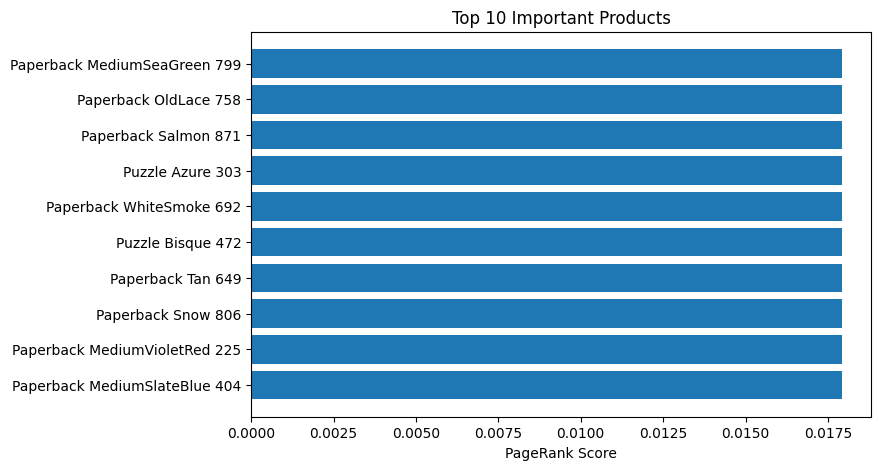

In [ ]:
plt.figure(figsize=(8,5))

plt.barh(top_products["product"], top_products["score"])
plt.xlabel("PageRank Score")
plt.title("Top 10 Important Products")

plt.gca().invert_yaxis()
plt.show()

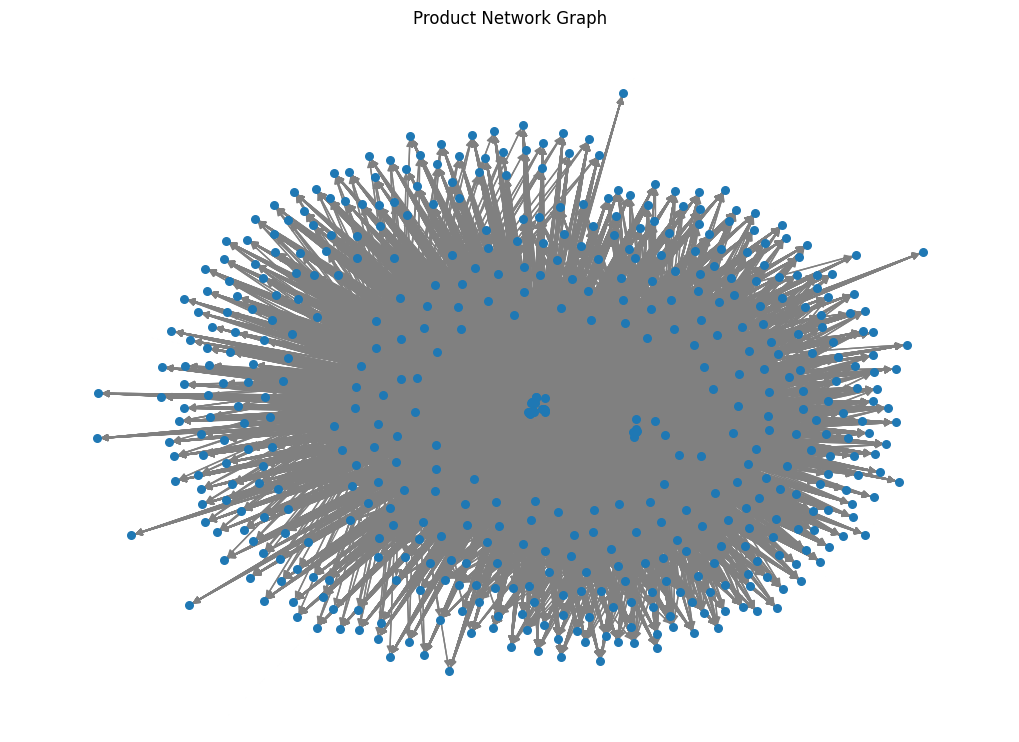

In [ ]:
plt.figure(figsize=(10,7))

pos = nx.spring_layout(G, k=0.5)

nx.draw(
    G,
    pos,
    node_size=30,
    with_labels=False,
    edge_color="gray"
)

plt.title("Product Network Graph")
plt.show()

In [ ]:
def recommend_with_pagerank(product_name, rules, pagerank_df, top_n=5):
    recs = rules[rules["antecedents"] == product_name]

    recs = recs.merge(
        pagerank_df,
        left_on="consequents",
        right_on="product",
        how="left"
    )

    recs = recs.sort_values(by=["lift", "score"], ascending=False)

    return recs[["consequents", "confidence", "lift", "score"]].head(top_n)